In [20]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn import datasets
import matplotlib.pyplot as plt

In [21]:
d = datasets.load_breast_cancer()
x, y = d.data, d.target

In [22]:
xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.2, random_state=42)

In [23]:
itr=[]
acc=[]

In [24]:
class MyLogisticRegression:
    def __init__(self, lr=0.001, n_iter=10):
        self.lr = lr
        self.max_iter = n_iter
        self.weights = None
        self.bias = None
        
    def fit(self, X, y):
        n_samples, n_features = X.shape
        
        #init parameters
        self.weights = np.zeros(n_features)
        self.bias = 0
        
        #gradient descent
        for i in range(self.max_iter):
            #approximate output variable (y) with linear combination of weights and input features (X) + bias
            linear_model = np.dot(X, self.weights) + self.bias
            #apply sigmoid function
            y_predicted = self._sigmoid(linear_model)
            
            #compute gradients
            dw = (1/n_samples) * np.dot(X.T, (y_predicted - y)) #derivative w.r.t weights
            db = (1/n_samples) * np.sum(y_predicted - y) #derivative w.r.t bias
            #Update parameters
            self.weights -= self.lr * dw
            self.bias -= self.lr * db
            
            itr.append(i)
            y_pred=self.predict(X)
            acur=self.accuracy(y, y_pred)
            acc.append(acur)
            
    def predict(self, X):
        linear_model = np.dot(X, self.weights) + self.bias
        y_predicted = self._sigmoid(linear_model)
        y_predicted_cls = [1 if i > 0.5 else 0 for i in y_predicted]
        return np.array(y_predicted_cls)
    
    def _sigmoid(self, x):
        return 1 / (1 + np.exp(-x))
    
    def accuracy(self, y_true, y_pred):
        accuracy = np.sum(y_true == y_pred) / len(y_true)
        return accuracy
    

In [25]:
regressor = MyLogisticRegression(lr=0.0001, n_iter=1000)
regressor.fit(xtrain, ytrain)
predictions = regressor.predict(xtest)

In [26]:
print("LR classification accuracy:", regressor.accuracy(ytest, predictions))
print(f"Iteration number {itr} and accuracy {acc}")

LR classification accuracy: 0.5
Iteration number [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 

In [27]:
regressor.weights

array([ 3.19808163e-02,  4.24678143e-02,  1.85446271e-01,  6.44528746e-02,
        2.88481782e-04, -1.54867878e-04, -5.95136403e-04, -2.54568301e-04,
        5.44427118e-04,  2.33704331e-04,  1.22235214e-04,  3.08037627e-03,
       -7.81530781e-04, -7.99648381e-02,  1.58168806e-05, -3.62585630e-05,
       -6.89717408e-05, -8.70415643e-06,  4.87250155e-05,  4.69200564e-06,
        3.36231472e-02,  5.25009944e-02,  1.86893932e-01, -1.22981938e-01,
        3.55871521e-04, -6.67398478e-04, -1.30481090e-03, -3.01629770e-04,
        6.99173646e-04,  2.12436087e-04])

In [28]:
regressor.bias

np.float64(0.004217790754381839)

Acc, 1000
Itr, 1000


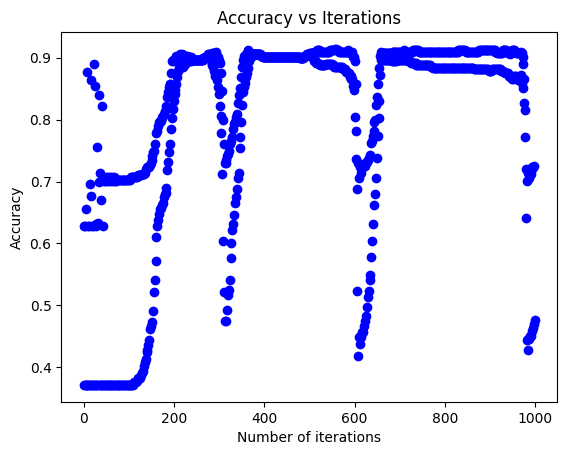

In [29]:
print("Acc,",len(acc))
print("Itr,",len(itr))
plt.scatter(itr, acc, color='blue')
plt.xlabel("Number of iterations")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Iterations")
plt.show()